## **Double-pendulum model by SREINet**


## **I. Setup and Preprocessing**

In [137]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG

# Tensowflow version should be 2.13.0 or
# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("*******************************|***************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()


opt_folder = 'output'
# Create the folder if it doesn't exist
os.makedirs(opt_folder, exist_ok=True)

**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
*******************************|***************


### **1.2 Training Data**

In [138]:
def load_double_pendulum_data(mat_path, downsample=1):
    """
    Loads double pendulum data from a MATLAB .mat file and returns the relevant arrays, with optional downsampling.
    Args:
        mat_path (str): Path to the .mat file.
        downsample (int): Take every nth sample (default 1, i.e., no downsampling)
    Returns:
        my_data (np.ndarray): Concatenated array of [theta1, theta2, d_theta1, d_theta2], shape (N, 4)
        d_theta (np.ndarray): Concatenated array of [d_theta1, d_theta2], shape (N, 2)
        time (np.ndarray): Time array
        dt (float): Time step
    """
    from scipy.io import loadmat
    import numpy as np

    data = loadmat(mat_path)
    theta1 = data['Theta1'][::downsample]
    theta2 = data['Theta2'][::downsample]
    d_theta1 = data['dTheta1'][::downsample]
    d_theta2 = data['dTheta2'][::downsample]

    my_data = np.concatenate([theta1, theta2, d_theta1, d_theta2], axis=1)
    d_theta = np.concatenate([d_theta1, d_theta2], axis=1)

    return my_data, d_theta

#### Create dataset

In [142]:
# Specify the model type
MY_DATA_TYPE = 'float32'

SEED = 42  # set seed for random number generation
np.random.seed(SEED)

import scipy.io as sio
import numpy as np
from skimage.transform import resize
import matplotlib.pyplot as plt
import cmocean

from sklearn.preprocessing import MinMaxScaler

from scipy.signal import savgol_filter


#load data
from scipy.io import loadmat

data_1, d_theta_1 = load_double_pendulum_data('DoublePendulum_Data/DoubleDataFreeSwing_1_Dt_0_001.mat',downsample=20)
data_2, d_theta_2 = load_double_pendulum_data('DoublePendulum_Data/DoubleDataFreeSwing_2_Dt_0_001.mat',downsample=20)

my_data = np.concatenate([data_1, data_2], axis=0)

dt = 0.001 * 20 #original dt



# Calculate derivative using Savitzky-Golay filter
window_length = 7  # Window length
polyorder = 2     # Polynomial order
dd_theta_1 = savgol_filter(d_theta_1, window_length, polyorder, delta=dt, deriv=1, axis=0)
dd_theta_2 = savgol_filter(d_theta_2, window_length, polyorder, delta=dt, deriv=1, axis=0)

derivative_data_1 = np.concatenate([d_theta_1, dd_theta_1], axis=1)
derivative_data_2 = np.concatenate([d_theta_2, dd_theta_2], axis=1)
derivative_data = np.concatenate([derivative_data_1, derivative_data_2], axis=0)


In [143]:
training_input = my_data
training_output = derivative_data


print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

Training input shape: (17669, 4)
Training output shape: (17669, 4)


### **1.3 Hyperparameters**


In [144]:
# Set mini-batch size
MINI_BATCH_SIZE = 32
learning_rate = 0.001

### **1.4 Model Architecture Definitions**


**SREINet Parameters**

In [145]:
# Assign dim to be the 2nd dimension of the training data (number of input variables)
dim = training_input.shape[1] 

guess_highest_order_polynomial = 3

layer_depth = guess_highest_order_polynomial
# The grid size of each dimension
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn)

[4, 4, 4]


## **II. Model and Training Preparation**


### **2.1 Create the SREINet Model**


In [146]:
my_activation = [lambda x:x,
                 lambda x:tf.cos(x),
                 lambda x:tf.sin(x),
                 lambda x:tf.cos(2*x),
                 lambda x:tf.sin(2*x),
                 #lambda x:tf.cos(3*x),
                 #lambda x:tf.sin(3*x),
                 ]

inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn, 1, 
                     activations=my_activation,
                     weight_initializer=tf.initializers.random_normal(stddev=1e-5, seed=SEED),
                     data_type=MY_DATA_TYPE,
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)



### **2.2 Loss Function**

In [147]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [148]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Trainer**

In [149]:
from sreinet_trainer import *

trainer = SREINetTrainer(model, my_optimizer, loss_fn, data_type='float32')

## **III.Training the Model**

### First two dimensions

#### **Pruning Profile**

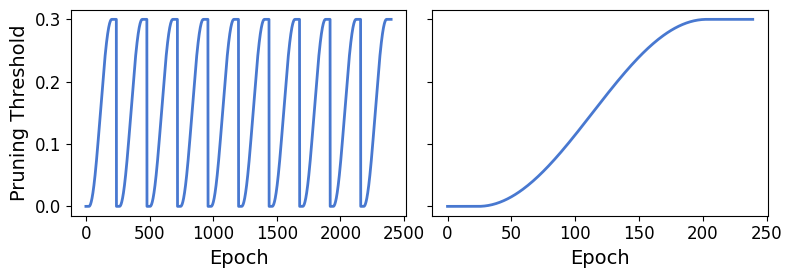

In [150]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.3 #Threshold for 10D Lorenz 96 model. Uses linear prune schedule
N_PERIODS = 10
PRUNING_EPOCHS_PER_PERIOD = 240
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

# Define the pruning schedule

pruning_scheduler = ps.PruningScheduler(steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                    num_periods=N_PERIODS,
                    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
                    zero_percentage=0.1,
                    show_plot=True)


### Training

In [151]:
#Setup
EARLY_STOPPING_LOSS_THRESHOLD = 1e-8  # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.1

training_histories = []
weights_list = []
loss_list = []


In [152]:
for i in range(0, 2):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]
    
    history = trainer.fit(training_input, output,
     batch_size=MINI_BATCH_SIZE, 
     validation_split=0.00,
     epochs=round(NUM_EPOCHS), 
     pruning_scheduler=pruning_scheduler,
     early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
     early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
     verbose=1,
     print_every_n_epochs=10,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    #reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)   

Training dimension 1...
Epoch   1 (Period 1):  Train Loss: 2.669e-01,  Epoch Time: 0.53s,  Current Pruning Threshold: 0
Epoch  11 (Period 1):  Train Loss: 2.926e-03,  Epoch Time: 0.32s,  Current Pruning Threshold: 0
Epoch  21 (Period 1):  Train Loss: 1.065e-03,  Epoch Time: 0.32s,  Current Pruning Threshold: 0
Epoch  31 (Period 1):  Train Loss: 5.905e-04,  Epoch Time: 0.32s,  Current Pruning Threshold: 0.00083091
Epoch  41 (Period 1):  Train Loss: 9.848e-05,  Epoch Time: 0.32s,  Current Pruning Threshold: 0.0058754
Epoch  51 (Period 1):  Train Loss: 4.688e-05,  Epoch Time: 0.31s,  Current Pruning Threshold: 0.015348
Epoch  61 (Period 1):  Train Loss: 2.647e-05,  Epoch Time: 0.32s,  Current Pruning Threshold: 0.028958
Epoch  71 (Period 1):  Train Loss: 4.330e-05,  Epoch Time: 0.32s,  Current Pruning Threshold: 0.046286
Epoch  81 (Period 1):  Train Loss: 3.501e-05,  Epoch Time: 0.32s,  Current Pruning Threshold: 0.066801
Epoch  91 (Period 1):  Train Loss: 6.674e-05,  Epoch Time: 0.32s,  

### Last three dimensions

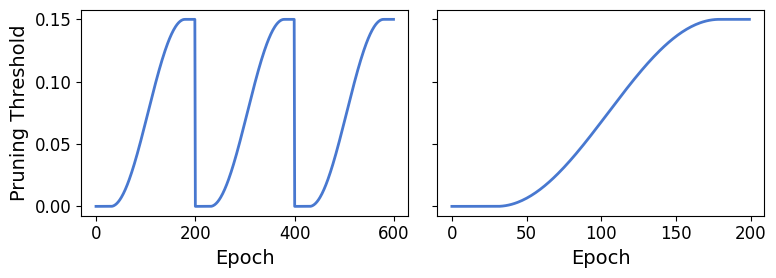

In [153]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.15 #Threshold for 10D Lorenz 96 model. Uses linear prune schedule
N_PERIODS = 3
PRUNING_EPOCHS_PER_PERIOD = 200
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

# Define the pruning schedule

pruning_scheduler = ps.PruningScheduler(steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                    num_periods=N_PERIODS,
                    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
                    zero_percentage=0.15,
                    show_plot=True)

In [154]:

EARLY_STOPPING_LOSS_THRESHOLD = 2e-1  # Threshold for early stopping
EARLY_STOPPING_PRUNING_THRESHOLD = 0.05

In [155]:
# For double pendulum, we only have 2 dimensions, so this loop is not needed
# But keeping it for consistency with the structure
for i in range(2, training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]

    history = trainer.fit(training_input, output,
     batch_size=MINI_BATCH_SIZE, 
     validation_split=0.20,
     epochs=round(NUM_EPOCHS), 
     pruning_scheduler=pruning_scheduler,
     early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
     early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
     verbose=1,
     print_every_n_epochs=10,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    #reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)      

Training dimension 3...
Epoch   1 (Period 1):  Train Loss: 5.339e+01,  Validation Loss: 1.040e+01,  Epoch Time: 0.47s,  Current Pruning Threshold: 0
Epoch  11 (Period 1):  Train Loss: 8.498e-01,  Validation Loss: 6.451e-01,  Epoch Time: 0.31s,  Current Pruning Threshold: 0
Epoch  21 (Period 1):  Train Loss: 5.216e-01,  Validation Loss: 5.367e-01,  Epoch Time: 0.31s,  Current Pruning Threshold: 0
Epoch  31 (Period 1):  Train Loss: 4.450e-01,  Validation Loss: 3.431e-01,  Epoch Time: 0.31s,  Current Pruning Threshold: 0
Epoch  41 (Period 1):  Train Loss: 3.561e-01,  Validation Loss: 2.974e-01,  Epoch Time: 0.31s,  Current Pruning Threshold: 0.0016609
Epoch  51 (Period 1):  Train Loss: 3.262e-01,  Validation Loss: 2.978e-01,  Epoch Time: 0.31s,  Current Pruning Threshold: 0.0065701
Epoch  61 (Period 1):  Train Loss: 3.101e-01,  Validation Loss: 3.274e-01,  Epoch Time: 0.31s,  Current Pruning Threshold: 0.01451
Epoch  71 (Period 1):  Train Loss: 3.181e-01,  Validation Loss: 3.347e-01,  Epo

## **IV. Coefficient Reconstructor (SREINet)**

#### `generate_set_labels`

In [156]:
def generate_layer_labels(N): # N is the number of neurons per layer
    num_terms = N // 5 # get the number of state variables. 

    return ['Constant'] + [f'x{i}' for i in range(1, num_terms+1)] + [f'cos(x{i})' for i in range(1, num_terms+1)] + [f'sin(x{i})' for i in range(1, num_terms+1)] + [f'cos(2*x{i})' for i in range(1, num_terms+1)] + [f'sin(2*x{i})' for i in range(1, num_terms+1)] 

def generate_LHS_labels(N):
    num_terms = N // 5
    return [f"(x{i})'" for i in range(1, num_terms+1)]

#### `coefficient_reconstruction`

In [157]:
from coefficient_reconstructor import *
cr = CoefficientReconstructor(generate_layer_labels, generate_LHS_labels)

## **V. Results**
### **Identified Model**

In [158]:
eq_str = []
for i in range(len(weights_list)):
    path_products = cr.reconstruct_coefficients(i,
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 1e-3,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")
        eq_str.append(dimension)

(x1)' = 1.000001169*x3
(x2)' = 1.000000106*x4
(x3)' = 0.2604689936 + 0.2950635791*x1 - 0.129873776*x2 + 0.07431053556*x3 + 0.6045620125*cos(x2) - 0.1807108979*cos(x3) + 0.02566818412*cos(x4) + 1.427914313*sin(x2) - 0.3895277209*sin(x3) - 0.03432671021*cos(2*x2) + 0.2282628848*sin(2*x1) + 0.6897657425*sin(2*x2) - 0.03610946584*sin(2*x3) + 0.008958843158*sin(2*x4) + 0.006594755429*x1*x4 + 0.005014900626*x3*x4 - 0.6269921547*sin(x1)*x4 + 0.1802569455*sin(x2)*x4 + 0.01429928306*sin(x3)*x4 - 0.02862233652*cos(2*x1)*x4 + 0.01364221668*cos(2*x2)*x4 + 0.1599678168*sin(2*x2)*x4 - 0.123285773*cos(x3)*x1 + 0.0692847571*cos(x3)*x2 - 0.002239741615*cos(x3)*x3 - 0.01819810854*cos(x1)*cos(x3) - 0.180979366*cos(x2)*cos(x3) - 0.007921164676*cos(x3)^2 + 0.03294010628*cos(x3)*cos(x4) - 0.4081854662*cos(x3)*sin(x1) + 0.3516996862*cos(x3)*sin(x2) + 0.05348265678*cos(x3)*sin(x3) - 0.02225516777*cos(x3)*sin(x4) + 0.09038277299*cos(2*x1)*cos(x3) - 0.001087330658*cos(2*x2)*cos(x3) - 0.002133162577*cos(2*x4)*co

### Validation

In [166]:
import importlib

import model_reconstructor as mr

importlib.reload(mr)

recovered_model = mr.RecoveredModel()
recovered_model.parse_ode_equations(eq_str)


val_t_span = [0,10]
val_t_eval = np.arange(0,10,dt)

# x includes theta and d_theta
val_x, val_d_theta = load_double_pendulum_data('DoublePendulum_Data/DoubleDataFreeSwing_4_Dt_0_001.mat',downsample=20)

data_initial_conditions = val_x[0]
SREINet_pred = recovered_model.simulate(data_initial_conditions, t_span=val_t_span, t_eval=val_t_eval, method='RK45')

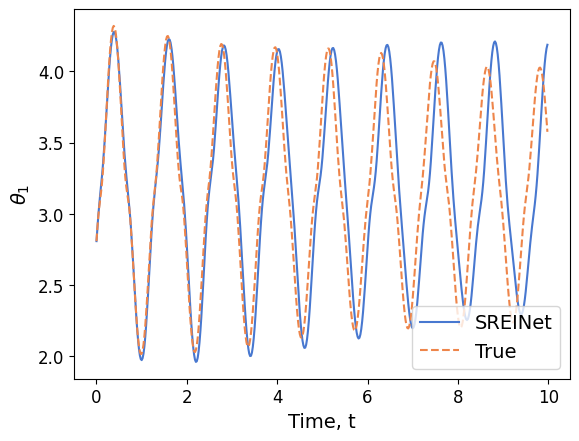

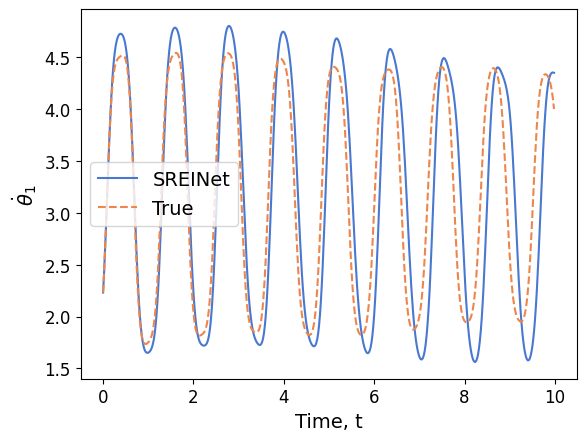

In [167]:
import matplotlib.pyplot as plt

plt.plot(SREINet_pred['t'], SREINet_pred['y'][0],label='SREINet')
plt.plot(val_t_eval, val_x[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time, t')
plt.ylabel(r'$\theta_1$')
plt.legend()
plt.show()


plt.plot(SREINet_pred['t'], SREINet_pred['y'][1],label='SREINet')
plt.plot(val_t_eval, val_x[:val_t_eval.shape[0],1], '--', label='True')
plt.xlabel('Time, t')
plt.ylabel(r'$\dot{\theta}_1$')
plt.legend()
plt.show()


In [168]:
#calculate derivatives 
pred_dx = recovered_model.predict_derivatives(SREINet_pred['y'].transpose())
pred_dx = pred_dx.transpose()

# Calculate derivative using Savitzky-Golay filter
window_length = 7  # Window length
polyorder = 2     # Polynomial order
val_dd_theta = savgol_filter(val_d_theta, window_length, polyorder, delta=dt, deriv=1, axis=0)

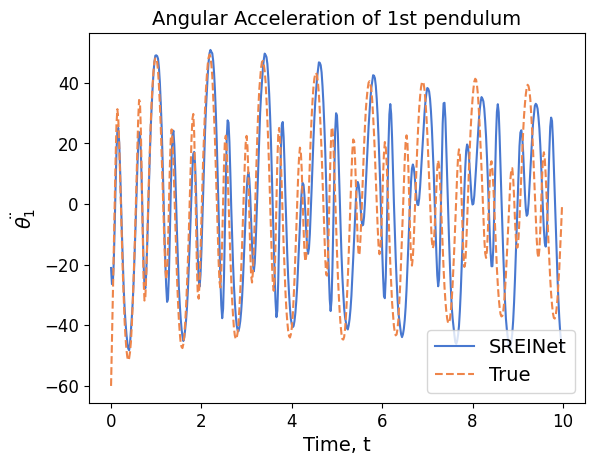

In [169]:
plt.plot(SREINet_pred['t'], pred_dx[2],label='SREINet')
plt.plot(val_t_eval, val_dd_theta[:val_t_eval.shape[0], 0], '--', label='True')
plt.xlabel('Time, t')
plt.ylabel(r'$\ddot{\theta_1}$')
plt.legend()
plt.title('Angular Acceleration of 1st pendulum')
plt.show()

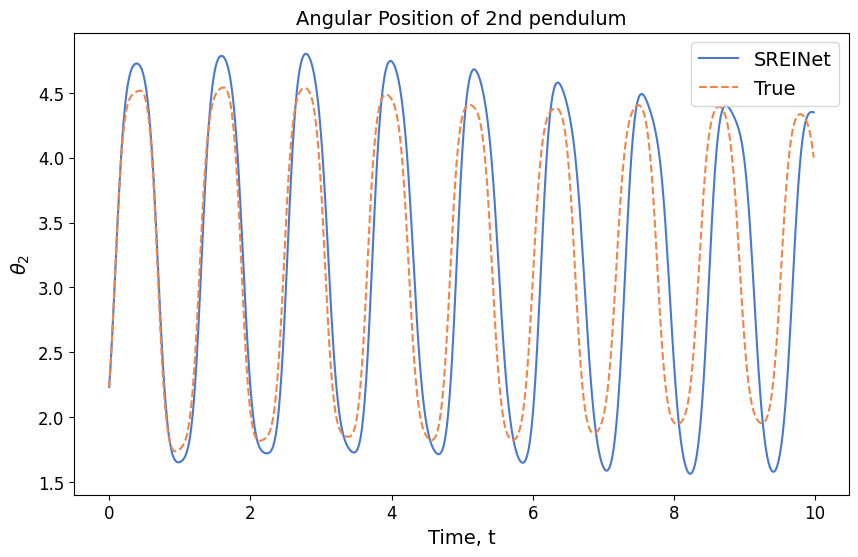

In [170]:
# Plot theta2
plt.figure(figsize=(10, 6))
plt.plot(SREINet_pred['t'], SREINet_pred['y'][1],label='SREINet')
plt.plot(val_t_eval, val_x[:val_t_eval.shape[0],1], '--', label='True')
plt.xlabel('Time, t')
plt.ylabel(r'$\theta_2$')
plt.legend()
plt.title('Angular Position of 2nd pendulum')
plt.show()


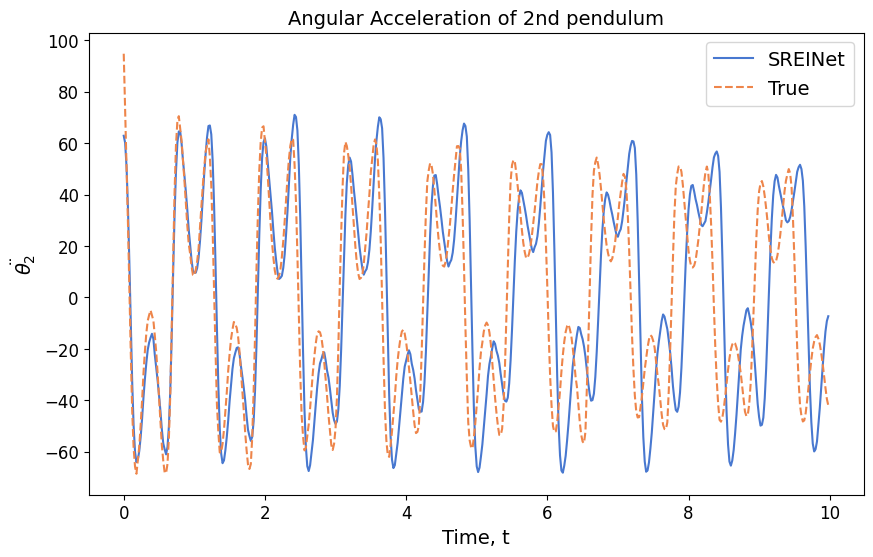

In [171]:
# Plot angular acceleration of 2nd pendulum
plt.figure(figsize=(10, 6))
plt.plot(SREINet_pred['t'], pred_dx[3],label='SREINet')
plt.plot(val_t_eval, val_dd_theta[:val_t_eval.shape[0], 1], '--', label='True')
plt.xlabel('Time, t')
plt.ylabel(r'$\ddot{\theta_2}$')
plt.legend()
plt.title('Angular Acceleration of 2nd pendulum')
plt.show()
